# 상품명 기반 군집화 실습 풀이

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 1. 데이터 로드 및 탐색

### 문제 1-1  
`pricerunner_aggregate.csv` 파일을 읽고 `Product Title` 컬럼의 상위 5개를 출력하시오.

In [8]:
# 파일 읽기
df = pd.read_csv('pricerunner_aggregate.csv')

# 데이터 기본 확인
print('데이터 크기:', df.shape)
print('\n컬럼 목록:')
print(df.columns.tolist())

# Product Title 상위 5개 출력
print('\n[Product Title 상위 5개]')
print(df['Product Title'].head())


데이터 크기: (35311, 7)

컬럼 목록:
['Product ID', 'Product Title', ' Merchant ID', ' Cluster ID', ' Cluster Label', ' Category ID', ' Category Label']

[Product Title 상위 5개]
0                      apple iphone 8 plus 64gb silver
1                  apple iphone 8 plus 64 gb spacegrau
2    apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...
3                  apple iphone 8 plus 64gb space grey
4    apple iphone 8 plus gold 5.5 64gb 4g unlocked ...
Name: Product Title, dtype: str


### 문제 1-2  
상품명이 비어 있거나 결측치인 행이 있는 경우, 해당 행은 삭제하시오.

In [9]:
# 결측치 개수 확인
print('삭제 전 Product Title 결측치 개수:', df['Product Title'].isna().sum())

# 공백 문자열도 결측처럼 처리하기 위해 문자열 양끝 공백 제거 후 빈 값 확인
df['Product Title'] = df['Product Title'].astype(str)
empty_mask = df['Product Title'].str.strip().eq('') | df['Product Title'].str.lower().eq('nan')

print('삭제 전 공백/비어있는 문자열 개수:', empty_mask.sum())

# 비어 있거나 결측치인 행 제거
df = df.loc[~empty_mask].copy()

print('삭제 후 데이터 크기:', df.shape)


삭제 전 Product Title 결측치 개수: 0
삭제 전 공백/비어있는 문자열 개수: 0
삭제 후 데이터 크기: (35311, 7)


## 2. 텍스트 전처리

### 문제 2-1  
모든 상품명을 소문자로 변환하고, 알파벳과 숫자를 제외한 문자는 모두 제거하여 `clean_title` 컬럼으로 저장하시오.

In [10]:
# 소문자 변환
# 알파벳(a-z), 숫자(0-9), 공백만 남기고 나머지 문자 제거
# 여러 공백은 하나로 정리
df['clean_title'] = (
    df['Product Title']
    .str.lower()
    .str.replace(r'[^a-z0-9\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

print(df[['Product Title', 'clean_title']].head())


                                       Product Title  \
0                    apple iphone 8 plus 64gb silver   
1                apple iphone 8 plus 64 gb spacegrau   
2  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...   
3                apple iphone 8 plus 64gb space grey   
4  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...   

                                         clean_title  
0                    apple iphone 8 plus 64gb silver  
1                apple iphone 8 plus 64 gb spacegrau  
2  apple mq8n2b a iphone 8 plus 64gb 5 5 12mp sim...  
3                apple iphone 8 plus 64gb space grey  
4  apple iphone 8 plus gold 5 5 64gb 4g unlocked ...  


## 3. TfidfVectorizer 벡터화

### 문제 3-1  
`TfidfVectorizer(stop_words='english', max_features=1000)`를 사용하여 상품명을 벡터화하시오. 생성된 벡터의 크기(shape)를 출력하시오.

In [11]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=1000
)

X = vectorizer.fit_transform(df['clean_title'])

print('벡터 shape:', X.shape)


벡터 shape: (35311, 1000)


## 4. 최적 클러스터 수 결정 (Silhouette Score)

Silhouette Score는 각 샘플이 자신의 군집에 얼마나 잘 속해 있는지, 그리고 다른 군집과는 얼마나 잘 분리되는지를 수치로 보여주는 지표이다.

- 값이 1에 가까울수록 군집이 잘 분리된 것이다.
- 값이 0에 가까우면 군집 간 경계가 겹친다.
- 음수이면 잘못 군집화되었을 가능성이 있다.

참고  
데이터가 많을 경우 Silhouette Score 계산은 시간이 다소 걸릴 수 있다. 아래 코드는 전체 데이터를 기준으로 수행한다.


### 문제 4-1  
KMeans를 사용하여 군집 수를 2~10까지 변화시키며 군집화를 수행하고, Silhouette Score를 계산하시오.

In [12]:
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f'k={k}, silhouette score={score:.4f}')


k=2, silhouette score=0.0202
k=3, silhouette score=0.0288
k=4, silhouette score=0.0367
k=5, silhouette score=0.0419
k=6, silhouette score=0.0502
k=7, silhouette score=0.0443
k=8, silhouette score=0.0517
k=9, silhouette score=0.0524
k=10, silhouette score=0.0546


### 문제 4-2  
각 클러스터 수에 대한 Silhouette Score를 시각화하여 최적의 클러스터 수를 선택하시오.

,k,silhouette_score
0,2,0.020165
1,3,0.028765
2,4,0.036727
3,5,0.041856
4,6,0.050239
5,7,0.044291
6,8,0.051702
7,9,0.052398
8,10,0.054622


선택된 최적 군집 수: 10
최고 Silhouette Score: 0.0546


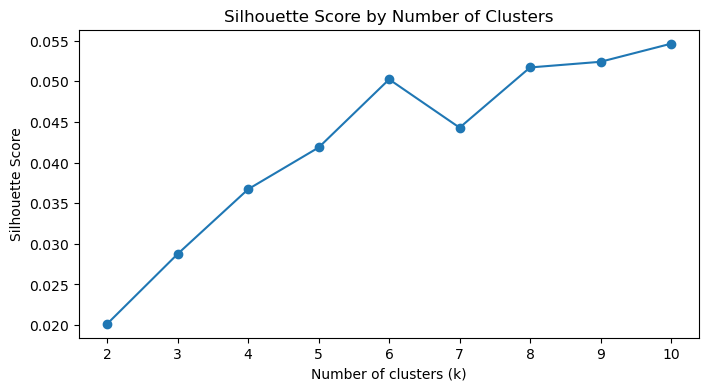

In [13]:
score_df = pd.DataFrame({
    'k': list(k_values),
    'silhouette_score': silhouette_scores
})

display(score_df)

best_k = score_df.loc[score_df['silhouette_score'].idxmax(), 'k']
best_score = score_df['silhouette_score'].max()

print(f'선택된 최적 군집 수: {best_k}')
print(f'최고 Silhouette Score: {best_score:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(score_df['k'], score_df['silhouette_score'], marker='o')
plt.xticks(list(k_values))
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.show()


## 5. KMeans 클러스터링

### 문제 5-1  
선택한 최적 클러스터 수를 기준으로 KMeans를 수행하고, 결과를 `df['cluster']` 컬럼에 저장하시오.

In [14]:
final_kmeans = KMeans(n_clusters=int(best_k), random_state=42, n_init=10)
df['cluster'] = final_kmeans.fit_predict(X)

print(df[['Product Title', 'clean_title', 'cluster']].head(10))
print('\n클러스터별 데이터 개수')
print(df['cluster'].value_counts().sort_index())


                                       Product Title  \
0                    apple iphone 8 plus 64gb silver   
1                apple iphone 8 plus 64 gb spacegrau   
2  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...   
3                apple iphone 8 plus 64gb space grey   
4  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...   
5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...   
6               apple iphone 8 plus 64 gb space grey   
7                apple iphone 8 plus 64gb space grey   
8                apple iphone 8 plus 64gb space grey   
9                apple iphone 8 plus 64gb space grey   

                                         clean_title  cluster  
0                    apple iphone 8 plus 64gb silver        1  
1                apple iphone 8 plus 64 gb spacegrau        1  
2  apple mq8n2b a iphone 8 plus 64gb 5 5 12mp sim...        1  
3                apple iphone 8 plus 64gb space grey        1  
4  apple iphone 8 plus gold 5 5 64gb 4g unlocked ...        1  

클러스터별 대표 단어를 간단히 확인해보면 각 군집의 주제를 더 쉽게 해석할 수 있다.

In [15]:
# 벡터화에 사용된 전체 단어 목록을 가져온다.
# TfidfVectorizer가 학습하면서 만든 단어 사전(vocabulary)의 순서가 그대로 담긴다.
feature_names = np.array(vectorizer.get_feature_names_out())

# KMeans가 학습한 각 클러스터의 중심점(centroid)을 가져온다.
# shape는 (클러스터 개수, 전체 단어 수) 형태이다.
# 각 중심점은 "해당 클러스터에 속한 문서들이 평균적으로 어떤 단어 특징을 가지는가"를 나타낸다.
centers = final_kmeans.cluster_centers_

top_n = 10

for cluster_idx in range(int(best_k)):

    # centers[cluster_idx] : 현재 클러스터 중심점의 단어별 가중치 배열
    # argsort() : 가중치를 오름차순으로 정렬했을 때의 인덱스를 반환
    # [::-1] : 내림차순으로 뒤집어서 가중치가 큰 단어부터 정렬
    # [:top_n] : 상위 10개 단어의 인덱스만 선택
    top_term_indices = centers[cluster_idx].argsort()[::-1][:top_n]

    # 위에서 구한 인덱스를 실제 단어(feature_names)로 변환
    # 현재 클러스터를 가장 잘 설명하는 단어 10개 추출
    top_terms = feature_names[top_term_indices]

    print(f'클러스터 {cluster_idx} 대표 단어: {", ".join(top_terms)}')

클러스터 0 대표 단어: microwave, oven, steel, built, stainless, grill, solo, black, 800w, bosch
클러스터 1 대표 단어: sim, siemens, black, washer, phone, samsung, mobile, dryer, ler, geschirrsp
클러스터 2 대표 단어: bosch, freezer, fridge, dishwasher, waschmaschine, hlger, mikrowelle, gefrierschrank, oven, built
클러스터 3 대표 단어: frost, free, freezer, fridge, white, standing, steel, 60cm, stainless, freestanding
클러스터 4 대표 단어: fridge, freezer, white, freestanding, integrated, larder, liebherr, smeg, counter, built
클러스터 5 대표 단어: camera, digital, canon, body, lens, eos, black, compact, 18, nikon
클러스터 6 대표 단어: washing, machine, white, 1400rpm, spin, 8kg, 9kg, 1400, 7kg, freestanding
클러스터 7 대표 단어: tv, hd, smart, led, 4k, hdr, ultra, inch, samsung, lg
클러스터 8 대표 단어: intel, processor, core, ghz, xeon, cache, mb, l3, socket, amd
클러스터 9 대표 단어: dishwasher, integrated, place, fully, slimline, 60cm, white, size, bosch, freestanding


## 6. 2차원 시각화 (보너스)

PCA를 사용해 2차원으로 축소한 뒤, 군집별 분포를 시각적으로 확인한다.

### 문제 6-1  
PCA를 사용하여 벡터를 2차원으로 축소하고, 클러스터별 색을 다르게 하여 시각화하시오.

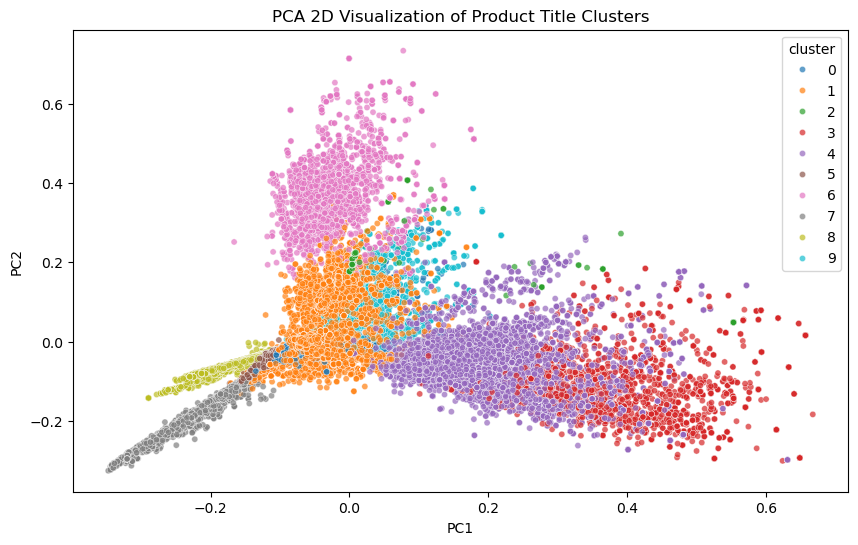

In [16]:
# 희소행렬을 밀집 배열로 변환한 뒤 PCA 수행
X_dense = X.toarray()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'cluster': df['cluster']
})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10',
    alpha=0.7,
    s=20
)
plt.title('PCA 2D Visualization of Product Title Clusters')
plt.legend(title='cluster')
plt.show()
